# Visualize all raw files

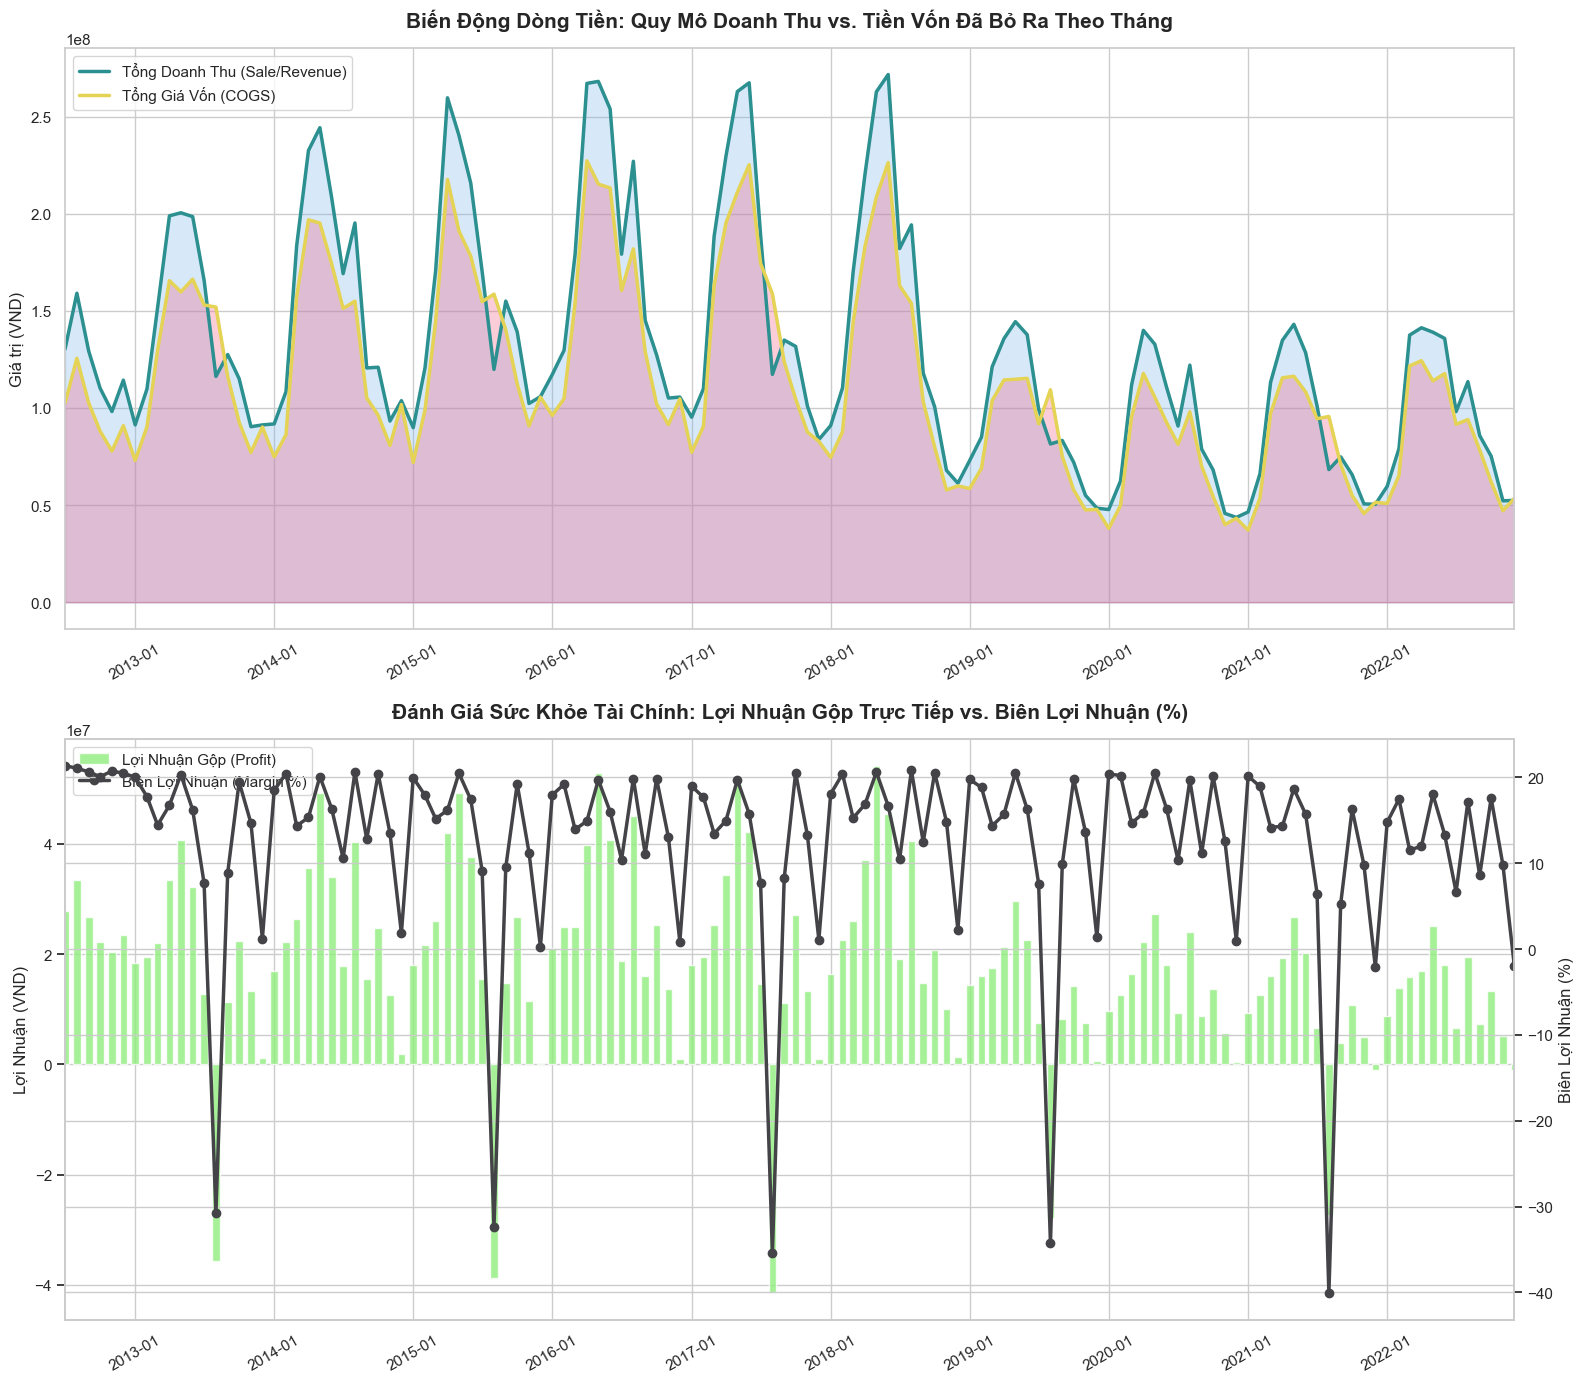

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# ==========================================
# 1. ĐỌC VÀ CHUẨN BỊ DỮ LIỆU
# ==========================================
df_sales = pd.read_csv('../dataset/sales.csv')

# Chuyển đổi định dạng Date và sắp xếp
df_sales['Date'] = pd.to_datetime(df_sales['Date'])
df_sales = df_sales.sort_values('Date')

# Dữ liệu theo ngày có thể rất nhiễu (răng cưa), ta sẽ gom nhóm theo Tháng (Month) để thấy xu hướng rõ ràng hơn
df_sales['YearMonth'] = df_sales['Date'].dt.to_period('M')
monthly_sales = df_sales.groupby('YearMonth').agg({
    'Revenue': 'sum',
    'COGS': 'sum'
}).reset_index()

# Chuyển đổi lại thành Datetime để dễ vẽ biểu đồ chuỗi thời gian
monthly_sales['Date'] = monthly_sales['YearMonth'].dt.to_timestamp()

# ==========================================
# 2. TÍNH TOÁN CÁC CHỈ SỐ TÀI CHÍNH CỐT LÕI
# ==========================================
# Lợi nhuận gộp (Gross Profit) = Doanh thu - Giá vốn
monthly_sales['Profit'] = monthly_sales['Revenue'] - monthly_sales['COGS']

# Biên lợi nhuận (Gross Margin) = (Lợi nhuận / Doanh thu) * 100
# Chỉ số này đo lường: Cứ 100 đồng bán ra thì thu về được bao nhiêu đồng lãi gộp?
monthly_sales['Margin_pct'] = (monthly_sales['Profit'] / monthly_sales['Revenue']) * 100

# ==========================================
# 3. TRỰC QUAN HÓA (VISUALIZATION)
# ==========================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(16, 14))

# -------------------------------------------------------------------
# BIỂU ĐỒ 1: SO SÁNH DOANH THU VÀ GIÁ VỐN (AREA CHART)
# -------------------------------------------------------------------
ax1 = axes[0]

# Vẽ biểu đồ miền (Area) để thấy rõ khối lượng tiền và "khoảng cách" lợi nhuận
ax1.fill_between(monthly_sales['Date'], monthly_sales['Revenue'], color='#7cb5ec', alpha=0.3)
ax1.plot(monthly_sales['Date'], monthly_sales['Revenue'], color='#2b908f', linewidth=2.5, label='Tổng Doanh Thu (Sale/Revenue)')

ax1.fill_between(monthly_sales['Date'], monthly_sales['COGS'], color='#f15c80', alpha=0.3)
ax1.plot(monthly_sales['Date'], monthly_sales['COGS'], color='#e4d354', linewidth=2.5, label='Tổng Giá Vốn (COGS)')

ax1.set_title('Biến Động Dòng Tiền: Quy Mô Doanh Thu vs. Tiền Vốn Đã Bỏ Ra Theo Tháng', fontsize=15, fontweight='bold', pad=15)
ax1.set_ylabel('Giá trị (VND)', fontsize=12)
ax1.legend(loc='upper left', fontsize=11)

# -------------------------------------------------------------------
# BIỂU ĐỒ 2: ĐÁNH GIÁ CHẤT LƯỢNG DÒNG TIỀN (LỢI NHUẬN VÀ BIÊN LỢI NHUẬN)
# -------------------------------------------------------------------
ax2 = axes[1]
# Tạo một trục Y thứ 2 (bên phải) để vẽ tỷ lệ phần trăm (Margin)
ax2_twin = ax2.twinx()

# Cột Lợi nhuận tuyệt đối (Trục trái) - Vẽ cột với width=20 ngày để không bị đè lên nhau
ax2.bar(monthly_sales['Date'], monthly_sales['Profit'], width=20, color='#90ed7d', alpha=0.8, label='Lợi Nhuận Gộp (Profit)')

# Đường Biên lợi nhuận (Trục phải)
ax2_twin.plot(monthly_sales['Date'], monthly_sales['Margin_pct'], color='#434348', marker='o', linewidth=2.5, label='Biên Lợi Nhuận (Margin %)')

ax2.set_title('Đánh Giá Sức Khỏe Tài Chính: Lợi Nhuận Gộp Trực Tiếp vs. Biên Lợi Nhuận (%)', fontsize=15, fontweight='bold', pad=15)
ax2.set_ylabel('Lợi Nhuận (VND)', fontsize=12)
ax2_twin.set_ylabel('Biên Lợi Nhuận (%)', fontsize=12)

# Gom chú thích của cả 2 trục vào chung một bảng
lines_1, labels_1 = ax2.get_legend_handles_labels()
lines_2, labels_2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=11)

# Định dạng chung cho trục X (Thời gian)
for ax in [ax1, ax2]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=30)
    
    # Giới hạn trục X để biểu đồ ôm sát dữ liệu
    ax.set_xlim(monthly_sales['Date'].min(), monthly_sales['Date'].max())

plt.tight_layout()
plt.show()